# 1. Load Library


In [ ]:
import json, sys, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D,ZeroPadding2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from os import listdir
import time
import math
import shutil
from tqdm import tqdm
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import RMSprop

# Kiểm tra GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. DATA PREPROCESSING AND DATA ANALYSIS

In [ ]:
#Lớp dùng để tăng cường dữ liệu (data augmentation) và chuẩn hóa ảnh trước khi đưa vào model.
train_datagen = ImageDataGenerator(
        rescale=1./255, # Chia tất cả giá trị pixel từ [0, 255] về [0, 1]
        shear_range=0.2,# Biến dạng (shear) ảnh theo góc (giúp model học tốt hơn)
        zoom_range=0.2,  # Phóng to / thu nhỏ ngẫu nhiên ảnh
        horizontal_flip=True) # Lật ngang ảnh ngẫu nhiên

# Validation và test chỉ chuẩn hóa (rescale) chứ không augmentation để giữ dữ liệu đánh giá trung thực.
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

# Phương thức này đọc ảnh từ thư mục, chia batch, và gắn nhãn dựa trên tên thư mục con.
# train sẽ là một data generator để huấn luyện model.
train = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/Project_cuoi_khoa/Data_set/training_set',
        target_size=(224, 224), # Resize toàn bộ ảnh về 224x224 pixel
        batch_size=32,           # Mỗi lần sinh 32 ảnh
        class_mode='binary')    # Vì bài toán phân loại 2 lớp → dùng binary
# test generator dùng cho đánh giá trên tập test.
test = test_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/Project_cuoi_khoa/Data_set/test_set',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary')
# validation generator dùng để kiểm tra hiệu suất model trong khi huấn luyện (validation accuracy/loss).
validation = val_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/Project_cuoi_khoa/Data_set/validation_set',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary')

Found 560 images belonging to 2 classes.
Found 240 images belonging to 2 classes.
Found 160 images belonging to 2 classes.


In [ ]:
print(train.class_indices)
print(test.class_indices)
print(validation.class_indices)

{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}
{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}
{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}


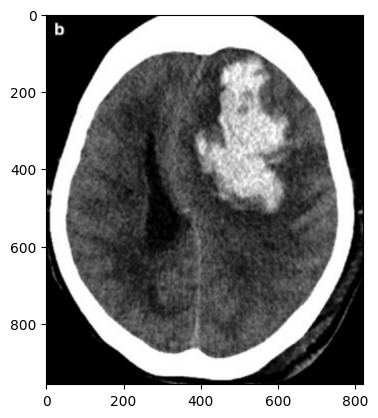

In [ ]:
# plt.imread(path) trả về một mảng NumPy chứa dữ liệu pixel:
# Nhận mảng ảnh (array) từ plt.imread() và hiển thị ra cửa sổ đồ họa.
plt.imshow(plt.imread("/content/drive/MyDrive/Colab Notebooks/Project_cuoi_khoa/Data_set/test_set/hemmorhage_data/000.png"))

# 3. Load MobileNet

In [ ]:
# Tải MobileNetV3 pretrained
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
# Define image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
# Base model
base_model = MobileNet(weights='imagenet',
                              include_top=False,
                              input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
                            )
base_model.trainable = True # Freeze all layers except the last few
for layer in base_model.layers[:50]:
  layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.7)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,229,889 (12.32 MB)

 Trainable params: 2,665,473 (10.17 MB)

 Non-trainable params: 564,416 (2.15 MB)

# 4. Tạo Model

In [ ]:
from pickle import HIGHEST_PROTOCOL
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 50  # You can adjust the number of epochs

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1, mode='min',min_delta=0.01) # You can adjust patience
his = model.fit(
    train,
    validation_data=validation,
    epochs=EPOCHS,
    callbacks=[early_stopping] # Add Early Stopping callback
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6299 - auc: 0.6647 - loss: 0.8408 - precision: 0.6169 - recall: 0.7132 - val_accuracy: 0.5000 - val_auc: 0.8341 - val_loss: 2.2535 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 695ms/step - accuracy: 0.8676 - auc: 0.9465 - loss: 0.3022 - precision: 0.8522 - recall: 0.8864 - val_accuracy: 0.5125 - val_auc: 0.9030 - val_loss: 1.8709 - val_precision: 0.5063 - val_recall: 1.0000
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 659ms/step - accuracy: 0.9370 - auc: 0.9862 - loss: 0.1500 - precision: 0.9322 - recall: 0.9447 - val_accuracy: 0.5250 - val_auc: 0.9260 - val_loss: 1.5057 - val_precision: 0.5128 - val_recall: 1.0000
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 600ms/step - accuracy: 0.9601 - auc: 0.9884 - loss: 0.1369 - precision: 0.9558 - recall: 0.9647 - val_accuracy: 0.7125 - val_auc: 0.9703 - val_loss: 0.6350 - val_precision: 0.6349 - val_recall: 1.0000
Epoch 5/50
18/18 ━━━━━━━━━━━━━━

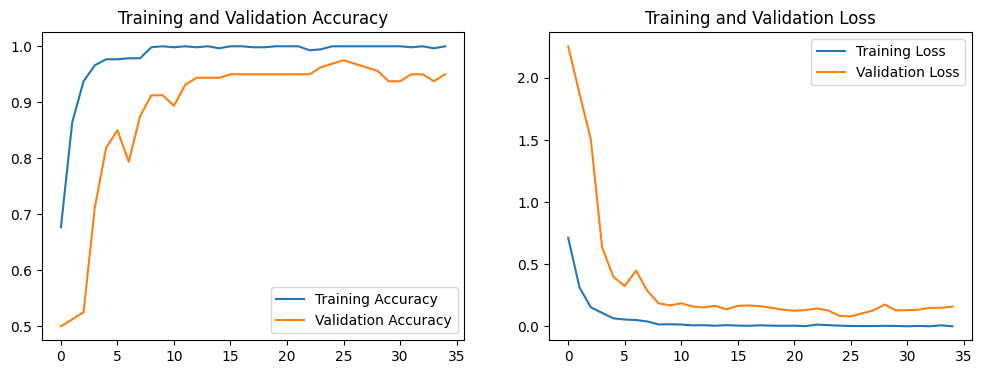

In [ ]:
acc = his.history['accuracy']
val_acc = his.history['val_accuracy']

loss = his.history['loss']
val_loss = his.history['val_loss']

epochs_range = range(35)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()